In [1]:
import numpy as np
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
class GaussianNB:

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes, n_features = len(self.classes_), X.shape[1] # shape[1] return nbr of column, [0] for rows

        self.means_ = np.zeros((n_classes, n_features))
        self.variances_ = np.zeros((n_classes, n_features))
        self.priors_ = np.zeros(n_classes)

        for idx, k in enumerate(self.classes_):
            Xk = X[y == k]

            self.means_[idx] = Xk.mean(axis=0)
            self.variances_[idx] = Xk.var(axis=0)
            self.priors_[idx] = Xk.shape[0] / X.shape[0]

        return self
    
    def _log_gaussian(self, X):
        num = -0.5 * (X[:,None,:] - self.means_)**2 / self.variances_
        log_prob = num - 0.5 * np.log(2 * np.pi * self.variances_)
        return log_prob.sum(axis=2)
    
    def predict(self, X):
        X = np.asarray(X)

        log_likelihood = self._log_gaussian(X)
        log_prior = np.log(self.priors_)

        return self.classes_[np.argmax(log_likelihood + log_prior, axis=1)]
    

In [3]:
X, y = load_breast_cancer(return_X_y=True)
print(X , end='\n')
print(y)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2 , random_state=42)
print(X_train , end='\n\n')
print(X_test , end='\n\n')
print(y_train, end='\n\n')
print(y_test)

[[9.029e+00 1.733e+01 5.879e+01 ... 1.750e-01 4.228e-01 1.175e-01]
 [2.109e+01 2.657e+01 1.427e+02 ... 2.903e-01 4.098e-01 1.284e-01]
 [9.173e+00 1.386e+01 5.920e+01 ... 5.087e-02 3.282e-01 8.490e-02]
 ...
 [1.429e+01 1.682e+01 9.030e+01 ... 3.333e-02 2.458e-01 6.120e-02]
 [1.398e+01 1.962e+01 9.112e+01 ... 1.827e-01 3.179e-01 1.055e-01]
 [1.218e+01 2.052e+01 7.722e+01 ... 7.431e-02 2.694e-01 6.878e-02]]

[[1.247e+01 1.860e+01 8.109e+01 ... 1.015e-01 3.014e-01 8.750e-02]
 [1.894e+01 2.131e+01 1.236e+02 ... 1.789e-01 2.551e-01 6.589e-02]
 [1.546e+01 1.948e+01 1.017e+02 ... 1.514e-01 2.837e-01 8.019e-02]
 ...
 [1.152e+01 1.493e+01 7.387e+01 ... 9.608e-02 2.664e-01 7.809e-02]
 [1.422e+01 2.785e+01 9.255e+01 ... 8.219e-02 1.890e-01 7.796e-02]
 [2.073e+01 3.112e+01 1.357e+02 ... 1.659e-01 2.868e-01 8.218e-02]]

[1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0
 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 1
 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1

In [5]:
model = GaussianNB()

In [6]:
model.fit(X_train, y_train)

In [7]:
y_predict = model.predict(X_test)
print(y_predict)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


In [8]:
print('Acurracy Score: ',metrics.accuracy_score(y_test, y_predict), end='\n\n')
print('Confusion Matrix: ',metrics.confusion_matrix(y_test, y_predict), end='\n\n')
print('Recall Score: ',metrics.recall_score(y_test, y_predict), end='\n\n')
print('Precision Score: ',metrics.precision_score(y_test, y_predict), end='\n\n')
print('F1 Score: ',metrics.f1_score(y_test, y_predict), end='\n\n')

Acurracy Score:  0.9649122807017544

Confusion Matrix:  [[40  3]
 [ 1 70]]

Recall Score:  0.9859154929577465

Precision Score:  0.958904109589041

F1 Score:  0.9722222222222222



(array([0, 1]), [Text(0, 0, 'malignant'), Text(0, 1, 'benign')])

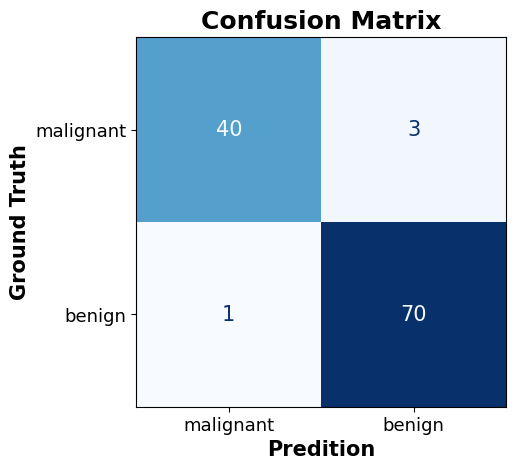

In [9]:
categorie_labels = ['malignant', 'benign']
cm = metrics.confusion_matrix(y_test, y_predict)
# disp = metrics.ConfusionMatrixDisplay(cm, display_labels=model.classes_)
# this diplay 1 and 0 (in rows & in column)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=categorie_labels)
# this diplay 'malignant' and 'benign' (in rows & in column)
disp.plot(cmap='Blues', colorbar=False, text_kw={'size': 15})

plt.xlabel('Predition', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

In [10]:
def save_Confusion_Matrix(cm, title, filename):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(filename)
    plt.close()

cm_native = [[40, 3], [1, 70]]
save_Confusion_Matrix(cm_native, 'Native GNB', 'native_cm.png')